# Forward vs Backward Classification
**Data:** All participants except Participant 4 (excluded)

**Sensor:** Trigno Discover IMU — Quaternion Orientation (W, X, Y, Z) at ~74 Hz

**Classes:** Forward, Backward (binary classification)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time

sns.set_style('whitegrid')
%matplotlib inline

## 2. Data Loading

In [2]:
BASE_DIR = os.path.join('..')

# Only Forward and Backward classes
CLASS_MAP = {'fw': 'Forward', 'bw': 'Backward'}

def load_participant_csv(filepath):
    """Load a single Trigno CSV, returning only the 4 quaternion columns."""
    df = pd.read_csv(filepath, header=None, skiprows=8, encoding='latin-1')
    df = df.iloc[:, :8]
    df.columns = ['time_W', 'W', 'time_X', 'X', 'time_Y', 'Y', 'time_Z', 'Z']
    df = df[['time_W', 'W', 'X', 'Y', 'Z']].rename(columns={'time_W': 'time'})
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    return df

def load_all_data(base_dir, exclude_participants=None):
    """Load data from all participants, optionally excluding some."""
    if exclude_participants is None:
        exclude_participants = []
    
    all_data = []
    
    for participant_dir in sorted(glob.glob(os.path.join(base_dir, 'Participant*'))):
        participant_name = os.path.basename(participant_dir)
        participant_num = int(participant_name.replace('Participant', ''))
        
        if participant_num in exclude_participants:
            continue
        
        for csv_file in sorted(glob.glob(os.path.join(participant_dir, '*.csv'))):
            filename = os.path.basename(csv_file)
            
            label = None
            for suffix, class_name in CLASS_MAP.items():
                if filename.endswith(f'_{suffix}.csv'):
                    label = class_name
                    break
            
            if label is None:
                continue
            
            df = load_participant_csv(csv_file)
            df['participant'] = participant_num
            df['class'] = label
            df['source_file'] = filename
            all_data.append(df)
    
    return pd.concat(all_data, ignore_index=True)

# Load data — all participants except Participant 4
df = load_all_data(BASE_DIR, exclude_participants=[4])

print(f'Data shape: {df.shape}')
print(f'Participants included: {sorted(df["participant"].unique())}')
print(f'Participant 4: EXCLUDED')
print(f'Classes: {df["class"].unique()}')

Data shape: (83847, 8)
Participants included: [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12]
Participant 4: EXCLUDED
Classes: ['Forward' 'Backward']


## 3. Data Exploration

In [3]:
# Basic info
print('=== Dataset Info ===')
print(df.info())
print()
print(df.describe())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83847 entries, 0 to 83846
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         83847 non-null  float64
 1   W            83847 non-null  float64
 2   X            83847 non-null  float64
 3   Y            83847 non-null  float64
 4   Z            83847 non-null  float64
 5   participant  83847 non-null  int64  
 6   class        83847 non-null  object 
 7   source_file  83847 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 5.1+ MB
None

               time             W             X             Y             Z  \
count  83847.000000  83847.000000  83847.000000  83847.000000  83847.000000   
mean      26.637493      0.884993      0.200042      0.022796      0.247460   
std       16.356374      0.074430      0.063750      0.123060      0.300441   
min        0.000000      0.639038     -0.066834     -0.250366     -

In [4]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
time           0
W              0
X              0
Y              0
Z              0
participant    0
class          0
source_file    0
dtype: int64


In [5]:
# Class distribution
print('Class distribution:')
print(df['class'].value_counts())

Class distribution:
class
Forward     43787
Backward    40060
Name: count, dtype: int64


Samples per participant per class:
class        Backward  Forward
participant                   
1                4420     4458
2                2591     4620
3                3312     3574
5                2738     3147
6                3101     3040
7                4700     4914
8                4675     4381
9                3145     3456
10               4190     4966
11               3438     3876
12               3750     3355


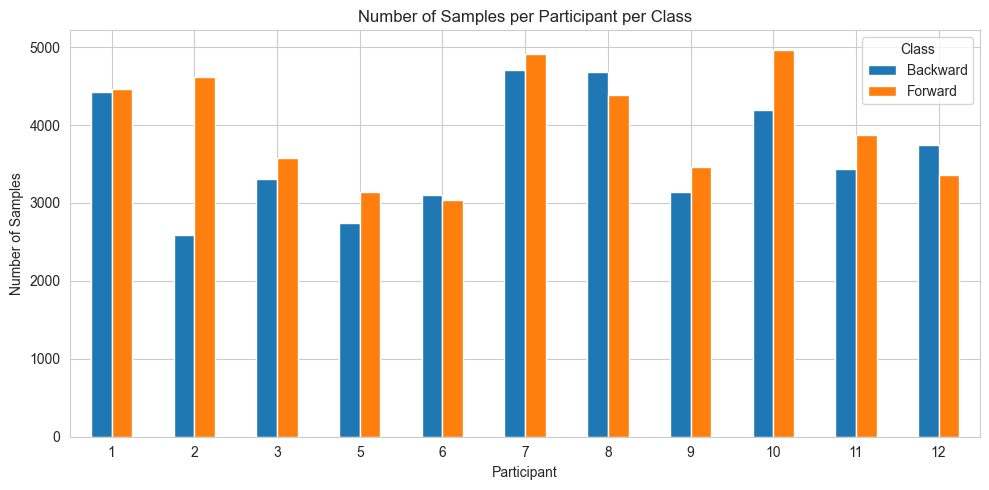

In [6]:
# Samples per participant per class
participant_class_counts = df.groupby(['participant', 'class']).size().unstack(fill_value=0)
print('Samples per participant per class:')
print(participant_class_counts)

fig, ax = plt.subplots(figsize=(10, 5))
participant_class_counts.plot(kind='bar', ax=ax)
ax.set_title('Number of Samples per Participant per Class')
ax.set_xlabel('Participant')
ax.set_ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.legend(title='Class')
plt.tight_layout()
plt.show()

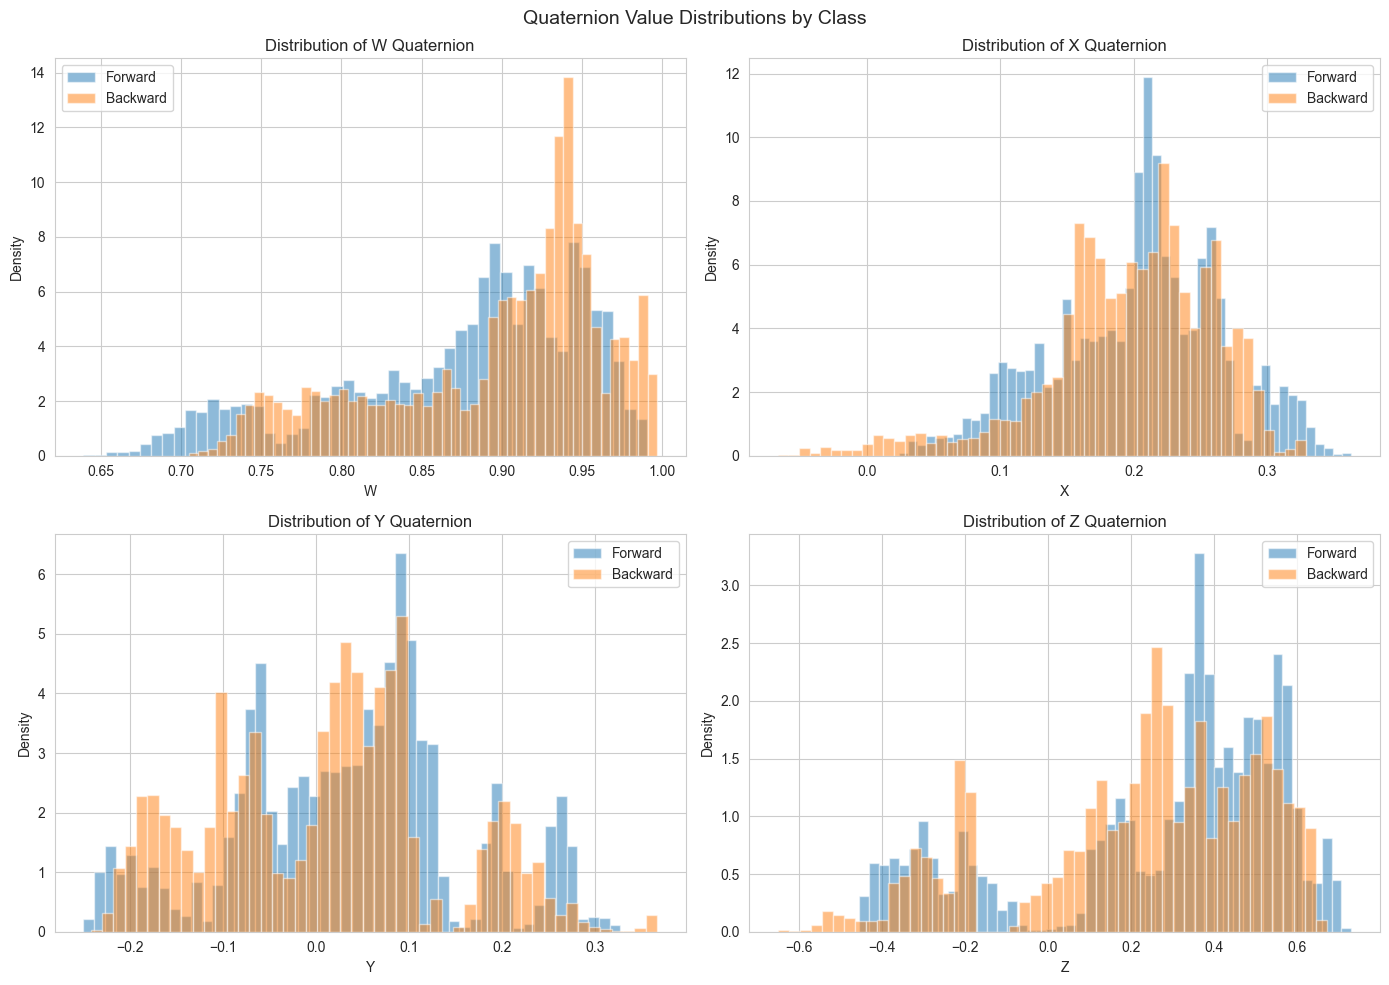

In [7]:
# Distribution of quaternion values by class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
quat_cols = ['W', 'X', 'Y', 'Z']

for ax, col in zip(axes.flatten(), quat_cols):
    for cls in CLASS_MAP.values():
        subset = df[df['class'] == cls][col]
        ax.hist(subset, bins=50, alpha=0.5, label=cls, density=True)
    ax.set_title(f'Distribution of {col} Quaternion')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Quaternion Value Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

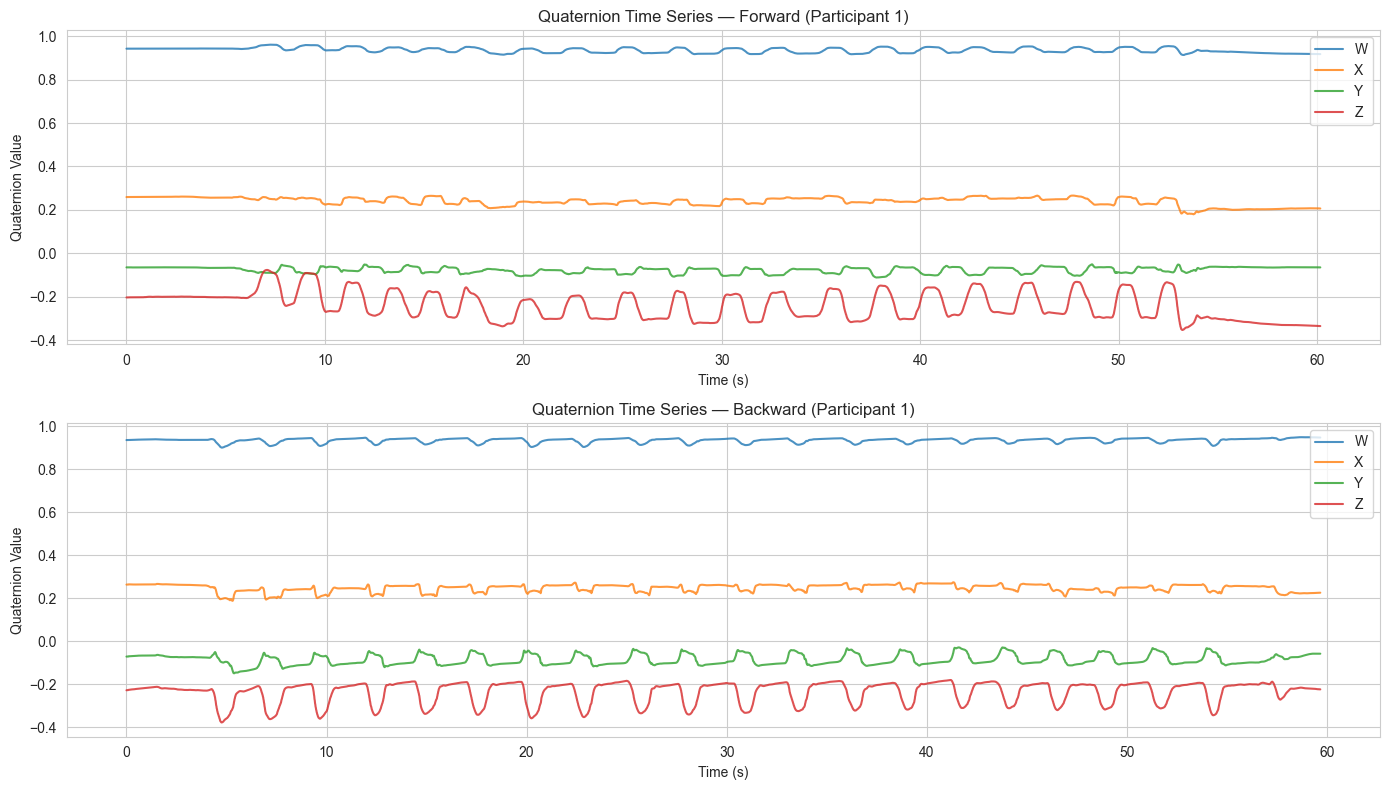

In [8]:
# Time series examples — one sample per class
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for ax, cls in zip(axes, CLASS_MAP.values()):
    sample_file = df[df['class'] == cls]['source_file'].unique()[0]
    sample = df[df['source_file'] == sample_file]
    for col in quat_cols:
        ax.plot(sample['time'].values, sample[col].values, label=col, alpha=0.8)
    ax.set_title(f'Quaternion Time Series — {cls} (Participant {sample["participant"].iloc[0]})')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Quaternion Value')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

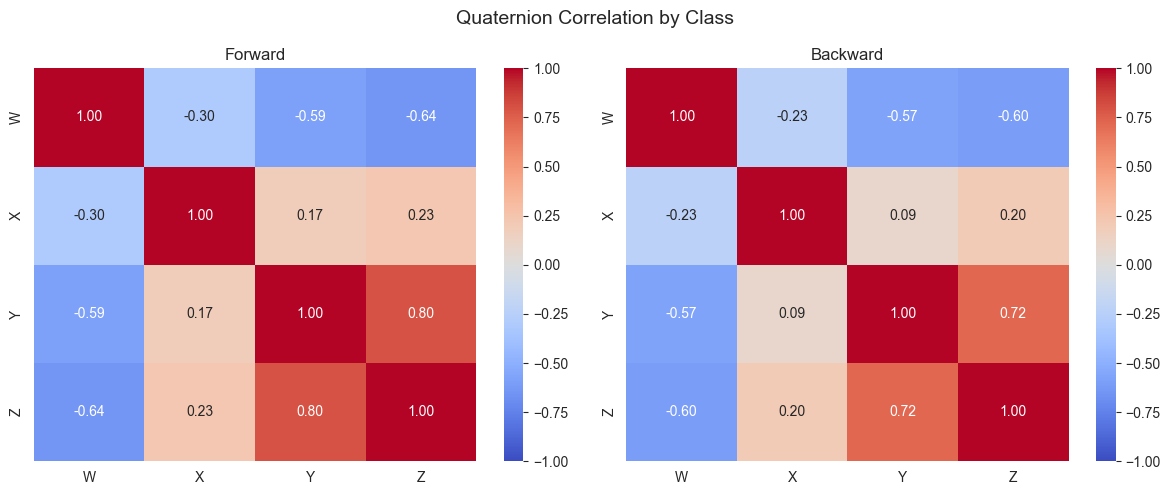

In [9]:
# Correlation heatmap of quaternion features
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cls in zip(axes, CLASS_MAP.values()):
    subset = df[df['class'] == cls][quat_cols]
    corr = subset.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
    ax.set_title(f'{cls}')

plt.suptitle('Quaternion Correlation by Class', fontsize=14)
plt.tight_layout()
plt.show()

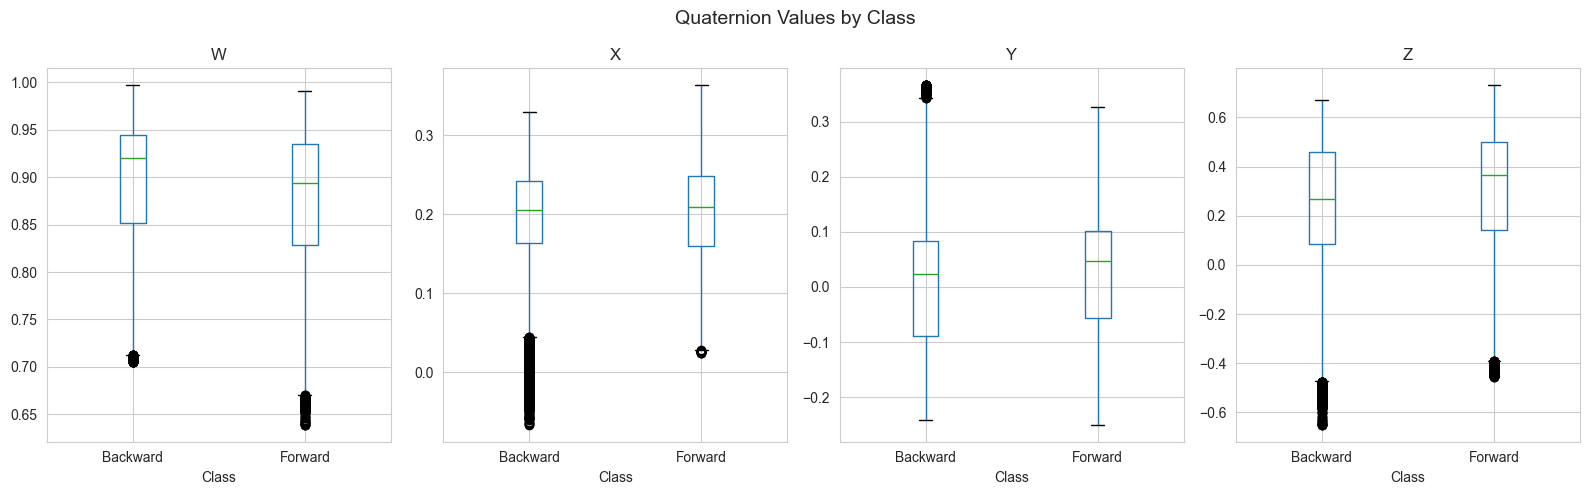

In [10]:
# Box plots per class
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, quat_cols):
    df.boxplot(column=col, by='class', ax=ax)
    ax.set_title(f'{col}')
    ax.set_xlabel('Class')

plt.suptitle('Quaternion Values by Class', fontsize=14)
plt.tight_layout()
plt.show()

## 4. IMU Preprocessing — Filtering, Normalization & Segmentation

In [11]:
### 4.1 Butterworth Low-Pass Filter
# Remove high-frequency noise from quaternion signals

SAMPLING_RATE = 74.0741  # Hz (from sensor metadata)
CUTOFF_FREQ = 5.0        # Hz — low-pass cutoff for human movement
FILTER_ORDER = 4

def butter_lowpass_filter(data, cutoff, fs, order):
    """Apply a Butterworth low-pass filter."""
    nyquist = 0.5 * fs
    normalized_cutoff = cutoff / nyquist
    b, a = butter(order, normalized_cutoff, btype='low')
    return filtfilt(b, a, data)

quat_cols = ['W', 'X', 'Y', 'Z']

def apply_filter_per_file(dataframe):
    """Apply Butterworth filter per source file (each recording independently)."""
    filtered_dfs = []
    for source_file in dataframe['source_file'].unique():
        file_df = dataframe[dataframe['source_file'] == source_file].copy()
        for col in quat_cols:
            file_df[col] = butter_lowpass_filter(file_df[col].values, CUTOFF_FREQ, SAMPLING_RATE, FILTER_ORDER)
        filtered_dfs.append(file_df)
    return pd.concat(filtered_dfs, ignore_index=True)

df = apply_filter_per_file(df)

print(f'Butterworth low-pass filter applied (cutoff={CUTOFF_FREQ} Hz, order={FILTER_ORDER})')
print(f'Data shape: {df.shape}')

Butterworth low-pass filter applied (cutoff=5.0 Hz, order=4)
Data shape: (83847, 8)


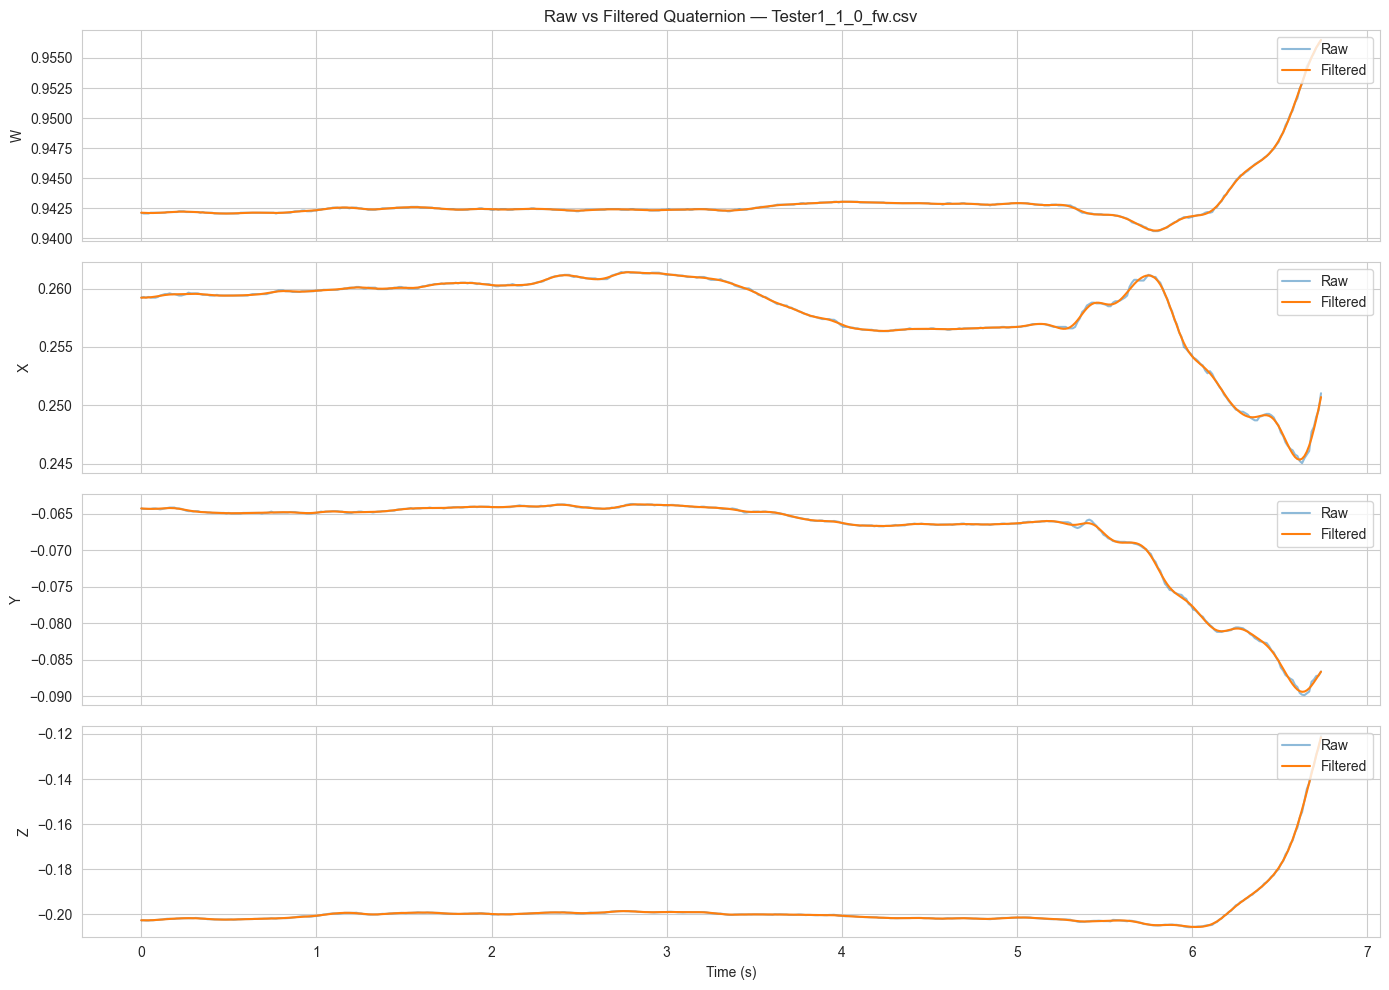

In [12]:
# Visualise raw vs filtered signal (one example)
sample_file = df['source_file'].unique()[0]
sample_raw = load_participant_csv(os.path.join(BASE_DIR, 
    f'Participant{df[df["source_file"]==sample_file]["participant"].iloc[0]}', sample_file))
sample_filt = df[df['source_file'] == sample_file]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, quat_cols):
    ax.plot(sample_raw['time'].values[:500], sample_raw[col].values[:500], alpha=0.5, label='Raw')
    ax.plot(sample_filt['time'].values[:500], sample_filt[col].values[:500], label='Filtered')
    ax.set_ylabel(col)
    ax.legend(loc='upper right')
axes[0].set_title(f'Raw vs Filtered Quaternion — {sample_file}')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [13]:
### 4.2 Normalization
# Min-Max normalize each recording independently to [0, 1]

def normalize_per_file(dataframe):
    """Min-Max normalize quaternion columns per source file."""
    normalized_dfs = []
    for source_file in dataframe['source_file'].unique():
        file_df = dataframe[dataframe['source_file'] == source_file].copy()
        for col in quat_cols:
            col_min = file_df[col].min()
            col_max = file_df[col].max()
            if col_max - col_min > 0:
                file_df[col] = (file_df[col] - col_min) / (col_max - col_min)
            else:
                file_df[col] = 0.0
        normalized_dfs.append(file_df)
    return pd.concat(normalized_dfs, ignore_index=True)

df = normalize_per_file(df)

print('Min-Max normalization applied per recording')
print(f'Quaternion ranges: {df[quat_cols].min().values} to {df[quat_cols].max().values}')

Min-Max normalization applied per recording
Quaternion ranges: [0. 0. 0. 0.] to [1. 1. 1. 1.]


In [14]:
### 4.3 Sliding Window Segmentation & Feature Extraction
# Segment each recording into fixed-size windows and extract statistical features

WINDOW_SIZE = 148   # ~2 seconds at 74 Hz
STEP_SIZE = 74      # 50% overlap (~1 second step)

def extract_window_features(window):
    """Extract statistical features from a single window of quaternion data."""
    features = []
    for col in quat_cols:
        signal = window[col].values
        features.extend([
            np.mean(signal),
            np.std(signal),
            np.min(signal),
            np.max(signal),
            np.median(signal),
            np.max(signal) - np.min(signal),         # range
            np.sqrt(np.mean(signal**2)),              # RMS
            np.sum(np.abs(np.diff(signal))),           # total variation
        ])
    return features

FEATURE_NAMES = []
for col in quat_cols:
    for stat in ['mean', 'std', 'min', 'max', 'median', 'range', 'rms', 'total_var']:
        FEATURE_NAMES.append(f'{col}_{stat}')

def segment_and_extract(dataframe):
    """Sliding window segmentation with feature extraction, per source file."""
    all_features = []
    all_labels = []
    
    for source_file in dataframe['source_file'].unique():
        file_df = dataframe[dataframe['source_file'] == source_file].reset_index(drop=True)
        label = file_df['class'].iloc[0]
        n_samples = len(file_df)
        
        for start in range(0, n_samples - WINDOW_SIZE + 1, STEP_SIZE):
            window = file_df.iloc[start:start + WINDOW_SIZE]
            features = extract_window_features(window)
            all_features.append(features)
            all_labels.append(label)
    
    return np.array(all_features), np.array(all_labels)

X_feat, y_labels = segment_and_extract(df)

print(f'Window size: {WINDOW_SIZE} samples (~{WINDOW_SIZE/SAMPLING_RATE:.1f}s)')
print(f'Step size:   {STEP_SIZE} samples (~{STEP_SIZE/SAMPLING_RATE:.1f}s, {(1 - STEP_SIZE/WINDOW_SIZE)*100:.0f}% overlap)')
print(f'Features per window: {len(FEATURE_NAMES)}')
print(f'\nTotal segments: {X_feat.shape}')
print(f'Class distribution: {dict(zip(*np.unique(y_labels, return_counts=True)))}')

Window size: 148 samples (~2.0s)
Step size:   74 samples (~1.0s, 50% overlap)
Features per window: 32

Total segments: (1102, 32)
Class distribution: {'Backward': 525, 'Forward': 577}


### 4.4 Feature Scaling & Train/Val/Test Split

In [15]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_labels)

# Train (60%) / Validation (20%) / Test (20%) split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_feat, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# StandardScaler — fit on training only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print(f'\nTraining set:   {X_train_scaled.shape[0]} segments ({X_train_scaled.shape[1]} features)')
print(f'Validation set: {X_val_scaled.shape[0]} segments')
print(f'Test set:       {X_test_scaled.shape[0]} segments')
print(f'\ny_train distribution: {np.bincount(y_train)}')
print(f'y_val distribution:   {np.bincount(y_val)}')
print(f'y_test distribution:  {np.bincount(y_test)}')

Label mapping: {'Backward': 0, 'Forward': 1}

Training set:   661 segments (32 features)
Validation set: 220 segments
Test set:       221 segments

y_train distribution: [315 346]
y_val distribution:   [105 115]
y_test distribution:  [105 116]


## 5. Random Forest — Training & Evaluation

In [16]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

start = time.time()
rf.fit(X_train_scaled, y_train)
train_time = time.time() - start

# Predictions
val_pred = rf.predict(X_val_scaled)
test_pred = rf.predict(X_test_scaled)

val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f'Random Forest trained in {train_time:.2f}s')
print(f'Validation Accuracy: {val_acc:.4f}')
print(f'Test Accuracy:       {test_acc:.4f}')

Random Forest trained in 0.17s
Validation Accuracy: 0.8682
Test Accuracy:       0.8507


In [17]:
# Classification Report
class_names = le.classes_
print('=== Classification Report — Test Set ===')
print(classification_report(y_test, test_pred, target_names=class_names))

=== Classification Report — Test Set ===
              precision    recall  f1-score   support

    Backward       0.85      0.84      0.84       105
     Forward       0.85      0.86      0.86       116

    accuracy                           0.85       221
   macro avg       0.85      0.85      0.85       221
weighted avg       0.85      0.85      0.85       221



### Confusion Matrix

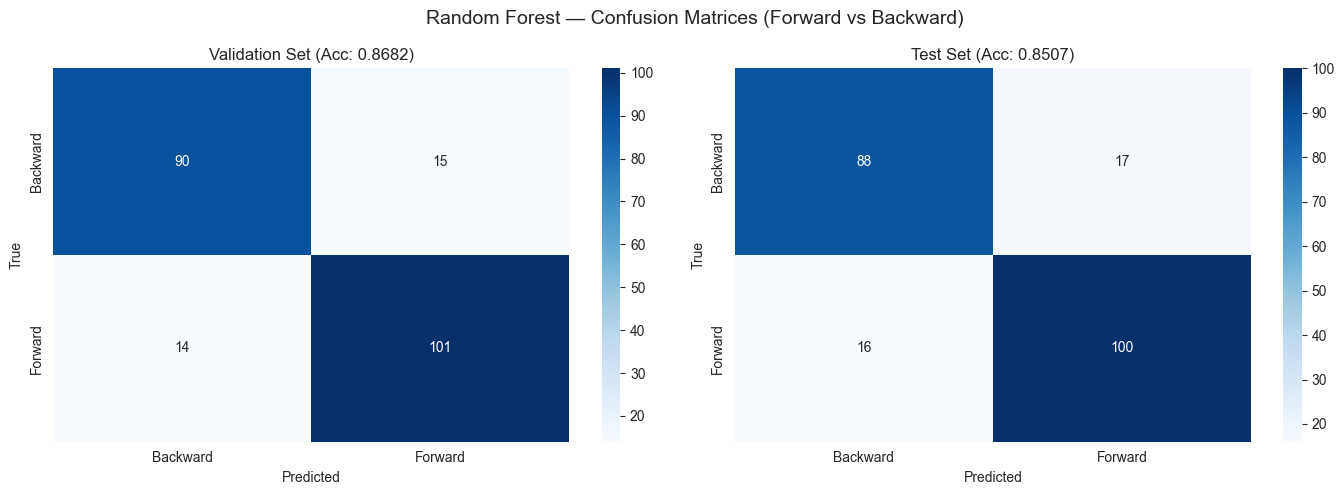

In [18]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation
cm_val = confusion_matrix(y_val, val_pred)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f'Validation Set (Acc: {val_acc:.4f})')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# Test
cm_test = confusion_matrix(y_test, test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title(f'Test Set (Acc: {test_acc:.4f})')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.suptitle('Random Forest — Confusion Matrices (Forward vs Backward)', fontsize=14)
plt.tight_layout()
plt.show()

### Feature Importance

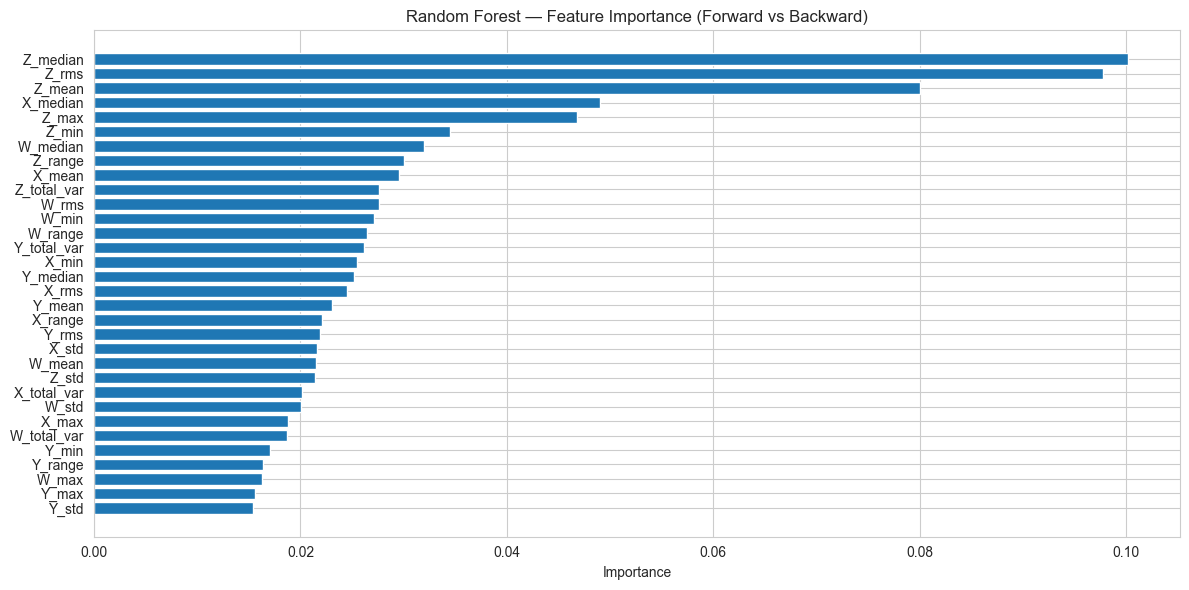


Top 10 features:
         Z_median: 0.1002
            Z_rms: 0.0978
           Z_mean: 0.0800
         X_median: 0.0491
            Z_max: 0.0468
            Z_min: 0.0345
         W_median: 0.0320
          Z_range: 0.0300
           X_mean: 0.0296
      Z_total_var: 0.0276


In [19]:
# Feature importance from Random Forest
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(FEATURE_NAMES)), importances[sorted_idx[::-1]])
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_yticklabels([FEATURE_NAMES[i] for i in sorted_idx[::-1]])
ax.set_xlabel('Importance')
ax.set_title('Random Forest — Feature Importance (Forward vs Backward)')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
for i in range(10):
    print(f'  {FEATURE_NAMES[sorted_idx[i]]:>15}: {importances[sorted_idx[i]]:.4f}')